# 🏅 120 Years of Olympic History: Does Home Field Advantage Exist?
**An Analysis of Host Country Performance in the Summer Olympics**

In this project, we explore the historical dataset of the Olympic Games to determine if the "Home Field Advantage" (HFA) is a real phenomenon. Specifically, we investigate whether host countries perform better in **Judged** sports compared to **Objective** sports, how this advantage has changed over time, and visually map the intensity of medals won by host cities.

## 1. Environment Setup & Data Loading
First, we will import the necessary libraries and download the dataset using `kagglehub`. We then load the data into a Pandas DataFrame.

In [15]:
import os
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import folium
from folium.plugins import HeatMap

# The Kagglehub is the library that interacts with the API to download datasets from the Kaggle website.
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "heesoo37/120-years-of-olympic-history-athletes-and-results",
    "athlete_events.csv",
)

# Print the first few rows to confirm it worked
print(df.head())

   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1   2                  A Lamusi   M  23.0   170.0    60.0           China   
2   3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN         Denmark   
3   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
4   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands   

   NOC        Games  Year  Season       City          Sport  \
0  CHN  1992 Summer  1992  Summer  Barcelona     Basketball   
1  CHN  2012 Summer  2012  Summer     London           Judo   
2  DEN  1920 Summer  1920  Summer  Antwerpen       Football   
3  DEN  1900 Summer  1900  Summer      Paris     Tug-Of-War   
4  NED  1988 Winter  1988  Winter    Calgary  Speed Skating   

                              Event Medal  
0       Basketball Men's Basketball   NaN  
1      Judo Men's Extra-Lightweight   NaN  
2           Football Men's

## 2. Data Cleaning & Preprocessing
To accurately evaluate the host countries, we need to clean team names (removing numeric suffixes like "Japan-1"). We will focus our analysis exclusively on the **Summer Olympics**. 

We also create a dictionary mapping each Summer Olympics year to its host country's NOC (National Olympic Committee) code to create an `Is_Host` boolean flag.

In [18]:
# Clean team names by removing numeric suffixes
df['Team_Clean'] = df['Team'].str.replace(r'-\d+$', '', regex=True)

print(f"Total Unique Countries: {len(df['Team_Clean'].unique())}")

# Separate Summer and Winter Olympics
summer_df = df[df['Season'] == 'Summer'].copy()
winter_df = df[df['Season'] == 'Winter'].copy()

print(f"Summer records: {len(summer_df)} | Winter records: {len(winter_df)}")

# Create a dictionary of all the hosts for each summer olympics based on NOC
summer_host_map = {
    2016: 'BRA', 2012: 'GBR', 2008: 'CHN', 2004: 'GRE', 2000: 'AUS',
    1996: 'USA', 1992: 'ESP', 1988: 'KOR', 1984: 'USA', 1980: 'URS',
    1976: 'CAN', 1972: 'FRG', 1968: 'MEX', 1964: 'JPN', 1960: 'ITA',
    1956: 'AUS', 1952: 'FIN', 1948: 'GBR', 1936: 'GER', 1932: 'USA',
    1928: 'NED', 1924: 'FRA', 1920: 'BEL', 1912: 'SWE', 1908: 'GBR',
    1904: 'USA', 1900: 'FRA', 1896: 'GRE'
}

# Add the summer_host_map to a new column as 'Host_NOC'
summer_df['Host_NOC'] = summer_df['Year'].map(summer_host_map)

# Add a boolean flag 'Is_Host'
summer_df['Is_Host'] = summer_df['NOC'] == summer_df['Host_NOC']

display(summer_df.head())

# Save the cleaned Summer Olympics dataset to a CSV file to upload in GitHub
output_filename = "Summer_Olympics_Cleaned_Dataset.csv"
summer_df.to_csv(output_filename, index=False)

print(f"File saved successfully: {output_filename}")

Total Unique Countries: 956
Summer records: 222552 | Winter records: 48564


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Team_Clean,Host_NOC,Is_Host
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,ESP,False
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,GBR,False
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,BEL,False
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark/Sweden,FRA,False
26,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,USA,False


File saved successfully: Summer_Olympics_Cleaned_Dataset.csv


## 3. Explatory Data Analysis (EDA)
We will use explatory data analysis to analyze whether being the host country leads to a higher probability of winning medals

Judged vs. Objective Sports
Are host nations favored more heavily in sports that rely on judges' scoring? 
To find out, we categorize sports into "Judged" (e.g., Gymnastics, Diving, Figure Skating) and "Objective" (e.g., Athletics, Swimming). We also calculate the Home Field Advantage (HFA) multiplier for both.

In [21]:
# Map medals to a numerical value and create a boolean medal flag
medal_mapping = {'Gold': 3, 'Silver': 2, 'Bronze': 1}
summer_df['Medal_Points'] = summer_df['Medal'].map(medal_mapping).fillna(0)
summer_df['Won_Medal'] = summer_df['Medal'].notna().astype(int)

# De-duplicate team sports to evaluate at the Country-Event level 
event_df = summer_df.sort_values('Medal_Points', ascending=False).drop_duplicates(
    subset=['Year', 'NOC', 'Event']
)

# Categorize EVERY sport into Judged vs. Objective
judged_sports = [
    'Gymnastics', 'Art Competitions', 'Diving', 'Synchronized Swimming',
    'Rhythmic Gymnastics', 'Figure Skating', 'Trampolining', 'Equestrianism',
    'Alpinism', 'Aeronautics'
]

# Binary classification
event_df['Sport_Type'] = np.where(event_df['Sport'].isin(judged_sports), 'Judged', 'Objective')

# Create explicit integer columns for analysis
event_df['Is_Host_Int'] = event_df['Is_Host'].astype(int)
event_df['Is_Judged_Int'] = (event_df['Sport_Type'] == 'Judged').astype(int)

# Calculate Medal Win Rate and HFA Multiplier
analysis = event_df.groupby(['Sport_Type', 'Is_Host'])['Won_Medal'].mean().unstack()
analysis.columns = ['Away_Win_Rate', 'Home_Win_Rate']
analysis['HFA_Multiplier'] = analysis['Home_Win_Rate'] / analysis['Away_Win_Rate']

print("--- Overall Host Advantage: Judged vs. Objective ---")
display(analysis)

--- Overall Host Advantage: Judged vs. Objective ---


,Away_Win_Rate,Home_Win_Rate,HFA_Multiplier
Sport_Type,,,
Judged,0.140896,0.358578,2.544982
Objective,0.136978,0.302403,2.207668


In [23]:
# Filter for only host nations
host_only_df = event_df[event_df['Is_Host'] == True]

# Group by specific sport to find the 'Home Field' leaders
top_judged_hosts = host_only_df[host_only_df['Sport_Type'] == 'Judged'].groupby('Sport')['Won_Medal'].mean().sort_values(ascending=False)

print("\n--- Success Rate of Hosts in Specific Judged Sports ---")
print(top_judged_hosts)


--- Success Rate of Hosts in Specific Judged Sports ---
Sport
Figure Skating           0.600000
Art Competitions         0.491525
Trampolining             0.428571
Equestrianism            0.424242
Gymnastics               0.340000
Diving                   0.292035
Synchronized Swimming    0.235294
Rhythmic Gymnastics      0.142857
Name: Won_Medal, dtype: float64


In [25]:
# Filter for only host nations
host_only_df = event_df[event_df['Is_Host'] == True]

# Group by specific sport to find the 'Home Field' leaders
top_objective_hosts = host_only_df[host_only_df['Sport_Type'] == 'Objective'].groupby('Sport')['Won_Medal'].mean().sort_values(ascending=False)

print("\n--- Success Rate of Hosts in Specific Objective Sports ---")
print(top_objective_hosts)


--- Success Rate of Hosts in Specific Objective Sports ---
Sport
Roque                1.000000
Croquet              1.000000
Racquets             1.000000
Rugby                1.000000
Lacrosse             1.000000
Jeu De Paume         1.000000
Tug-Of-War           1.000000
Cricket              1.000000
Motorboating         0.666667
Archery              0.600000
Hockey               0.533333
Softball             0.500000
Water Polo           0.451613
Tennis               0.439394
Beach Volleyball     0.416667
Polo                 0.400000
Rowing               0.398990
Cycling              0.394231
Boxing               0.391892
Sailing              0.386503
Taekwondo            0.375000
Golf                 0.333333
Weightlifting        0.323741
Volleyball           0.285714
Shooting             0.278226
Wrestling            0.275449
Swimming             0.272381
Athletics            0.256944
Football             0.250000
Badminton            0.238095
Basketball           0.233333
Judo

In [27]:
# 1. Calculate the mean medal win rate (probability) for each Sport, split by Host status
sport_adv = event_df.groupby(['Sport', 'Is_Host'])['Won_Medal'].mean().unstack()

# 2. Calculate the 'Home Field Advantage' metric
# This represents the percentage point increase in medal probability when competing at home
sport_adv['Host_adv'] = sport_adv[True] - sport_adv[False]

# 3. Rank the sports from highest advantage to lowest
# Positive values indicate a 'boost' at home; negative would indicate underperformance at home
sport_adv = sport_adv.sort_values('Host_adv', ascending=False)

# 4. Display the top 10 sports where the host nation sees the most significant benefit
sport_adv.head(10)

Is_Host,False,True,Host_adv
Sport,,,
Archery,0.115016,0.600000,0.484984
Tug-Of-War,0.588235,1.000000,0.411765
Tennis,0.137203,0.439394,0.302191
Beach Volleyball,0.126316,0.416667,0.290351
Art Competitions,0.210000,0.491525,0.281525
Hockey,0.255521,0.533333,0.277813
Cycling,0.131545,0.394231,0.262686
Sailing,0.131420,0.386503,0.255083
Boxing,0.146685,0.391892,0.245206


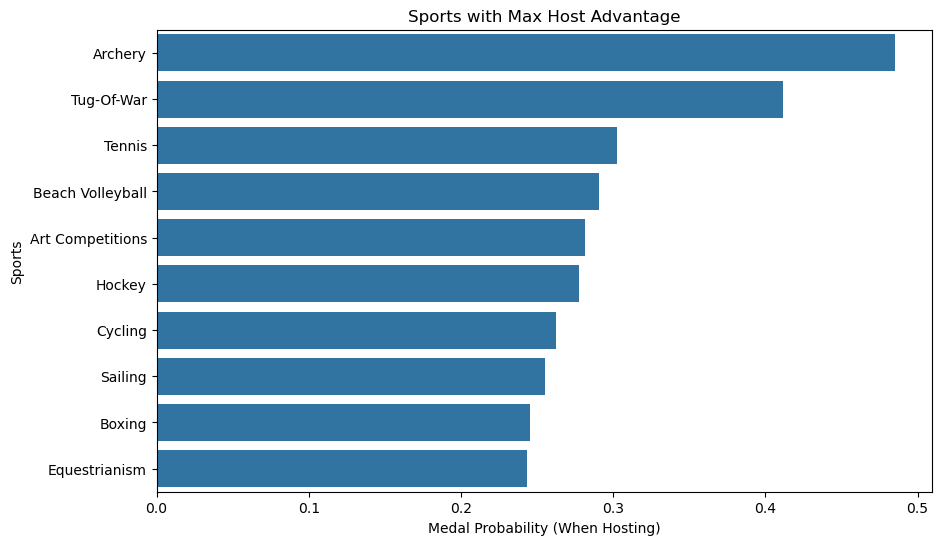

In [29]:
# Create a horizontal bar chart
# x='Host_adv' shows the win probability gap; y='Sport' labels each bar
top_sports = sport_adv.head(10).reset_index()

plt.figure(figsize=(10,6))

sns.barplot(data=top_sports, x='Host_adv', y='Sport')

plt.title("Sports with Max Host Advantage")
plt.xlabel("Medal Probability (When Hosting)")
plt.ylabel("Sports")

plt.show()

### 4.1 Model Creation: Logistic Regression Analysis
We will run a logistic regression to test if the interaction of being the Host and competing in a Judged sport significantly predicts winning a medal.

In [32]:
# Regression model: Does the interaction of Hosting and being a Judged sport significantly predict winning a medal?
model = smf.logit('Won_Medal ~ Is_Host_Int * Is_Judged_Int', data=event_df).fit()

print("--- Statistical Significance of the Host Advantage ---")
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.410379
         Iterations 6
--- Statistical Significance of the Host Advantage ---
                           Logit Regression Results                           
Dep. Variable:              Won_Medal   No. Observations:                98157
Model:                          Logit   Df Residuals:                    98153
Method:                           MLE   Df Model:                            3
Date:                Fri, 13 Mar 2026   Pseudo R-squ.:                 0.01050
Time:                        15:39:46   Log-Likelihood:                -40282.
converged:                       True   LL-Null:                       -40709.
Covariance Type:            nonrobust   LLR p-value:                4.528e-185
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept              

### 4.2 Visualizing the Advantage
Let's graph the probability of winning a medal for Host vs. Non-Host countries across our two sport categories.

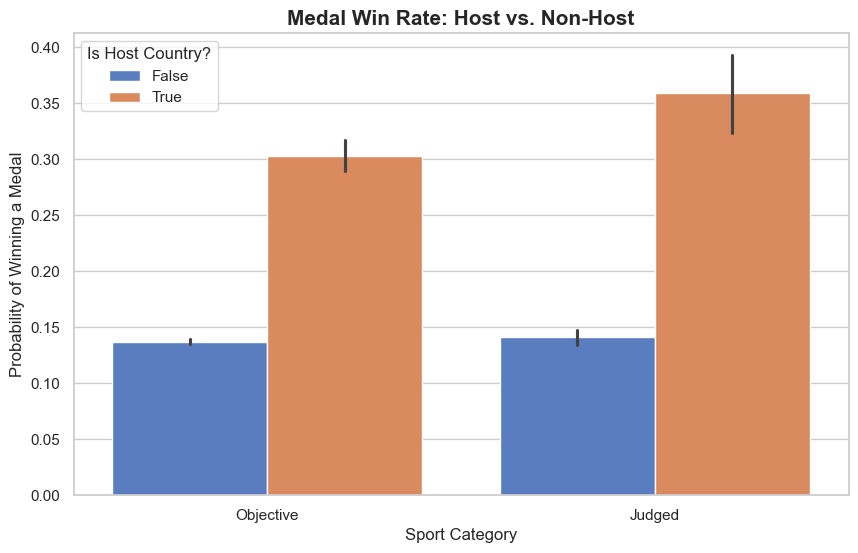

In [35]:
# Set professional style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plotting the Medal Win Rate
ax = sns.barplot(x='Sport_Type', y='Won_Medal', hue='Is_Host', data=event_df, palette='muted')

# Customizing for Professional Quality
plt.title('Medal Win Rate: Host vs. Non-Host', fontsize=15, fontweight='bold')
plt.ylabel('Probability of Winning a Medal', fontsize=12)
plt.xlabel('Sport Category', fontsize=12)
plt.legend(title='Is Host Country?')

plt.show()

## 5. Geospatial Heatmap of Host City Success
Let's visualize where host countries historically rack up their medals using a `Folium` Heatmap. We map out the coordinates of historical Summer Olympic host cities and weight them by the total medals won by the host country during those games.

In [38]:
# Coordinate mapping for Summer Olympic Host Cities
city_coords = {
    'Rio de Janeiro': [-22.9068, -43.1729], 'London': [51.5074, -0.1278],
    'Beijing': [39.9042, 116.4074], 'Athina': [37.9838, 23.7275],
    'Sydney': [-33.8688, 151.2093], 'Atlanta': [33.7490, -84.3880],
    'Barcelona': [41.3851, 2.1734], 'Seoul': [37.5665, 126.9780],
    'Los Angeles': [34.0522, -118.2437], 'Moskva': [55.7558, 37.6173],
    'Montreal': [45.5017, -73.5673], 'Munich': [48.1351, 11.5820],
    'Mexico City': [19.4326, -99.1332], 'Tokyo': [35.6895, 139.6917],
    'Roma': [41.9028, 12.4964], 'Melbourne': [-37.8136, 144.9631],
    'Helsinki': [60.1699, 24.9384], 'Berlin': [52.5200, 13.4050],
    'Amsterdam': [52.3676, 4.9041], 'Paris': [48.8566, 2.3522],
    'Antwerpen': [51.2194, 4.4025], 'Stockholm': [59.3293, 18.0686],
    'St. Louis': [38.6270, -90.1994]
}

# 1. Aggregate total medals won by hosts per city
heatmap_base = event_df[event_df['Is_Host'] == True].groupby('City')['Won_Medal'].sum().reset_index()

# 2. Map coordinates and create the weight (intensity) column
heatmap_base['lat'] = heatmap_base['City'].map(lambda x: city_coords.get(x, [None])[0])
heatmap_base['lon'] = heatmap_base['City'].map(lambda x: city_coords.get(x, [None, None])[1])

# 3. Create a list of [lat, lon, weight] for the HeatMap plugin
heat_data = heatmap_base.dropna(subset=['lat', 'lon'])[['lat', 'lon', 'Won_Medal']].values.tolist()

# Create the base map
m = folium.Map(location=[20, 0], zoom_start=2, tiles="CartoDB dark_matter")

# Add the HeatMap layer (Intensity is based on 'Won_Medal')
HeatMap(heat_data,
        radius=25,
        blur=15,
        min_opacity=0.5,
        gradient={0.4: 'blue', 0.65: 'lime', 1: 'red'}
       ).add_to(m)

# Save the map as a separate file
m.save('olympic_host_intensity.html')
m

## 6. Time Series: Host Advantage Over Time
Finally, we want to see how the Host Advantage has evolved over the 120 years of Olympic history. We aggregate the data by decades to smooth out the noise and plot the difference in win rates over time.

Is_Host,Year_flat,False,True,Host_Advantage
0,1890,0.484615,0.743590,0.258974
1,1900,0.339286,0.792254,0.452968
2,1910,0.243728,0.473684,0.229957
3,1920,0.219717,0.252841,0.033124
4,1930,0.179099,0.622642,0.443542


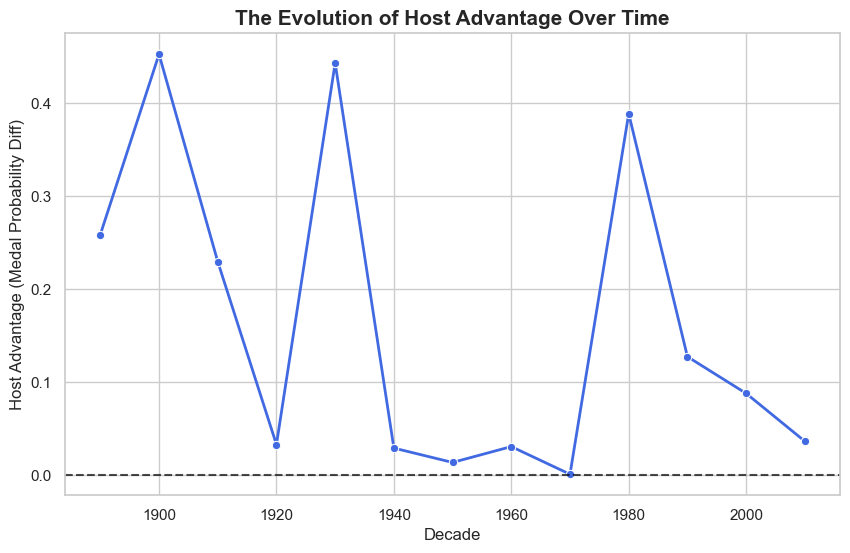

In [41]:
# Flatten the years to decades (e.g., 1896 -> 1890) to remove noise
event_df['Year_flat'] = (event_df['Year'] // 10) * 10

# Calculate the trend
trend = event_df.groupby(['Year_flat','Is_Host'])['Won_Medal'].mean().unstack()
trend['Host_Advantage'] = trend[True] - trend[False]
trend.reset_index(inplace=True)

display(trend.head())

# Plotting the trend over time
plt.figure(figsize=(10,6))
sns.lineplot(data=trend, x='Year_flat', y='Host_Advantage', marker='o', linewidth=2, color='royalblue')

plt.title("The Evolution of Host Advantage Over Time", fontsize=15, fontweight='bold')
plt.ylabel("Host Advantage (Medal Probability Diff)", fontsize=12)
plt.xlabel("Decade", fontsize=12)
plt.axhline(0, linestyle='--', color='black', alpha=0.7)

plt.show()

---
## Conclusion
This analysis successfully demonstrates that the "Home Field Advantage" is a tangible factor in the Summer Olympics, particularly evident through logistic regression and historical visualizations. The data suggests that being a host country amplifies the probability of winning medals, with specific variations depending on the subjectivity (judged vs. objective) of the sport itself.